In [55]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets

train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transforms.ToTensor(), download=True)

/Users/emrullahdagkusu/Documents/Mac/26SS/Lab Vision Systems/vision-systems/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Number of training samples: 50000
Number of test samples: 10000
Shape of a single image: torch.Size([3, 32, 32])
Classes in CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


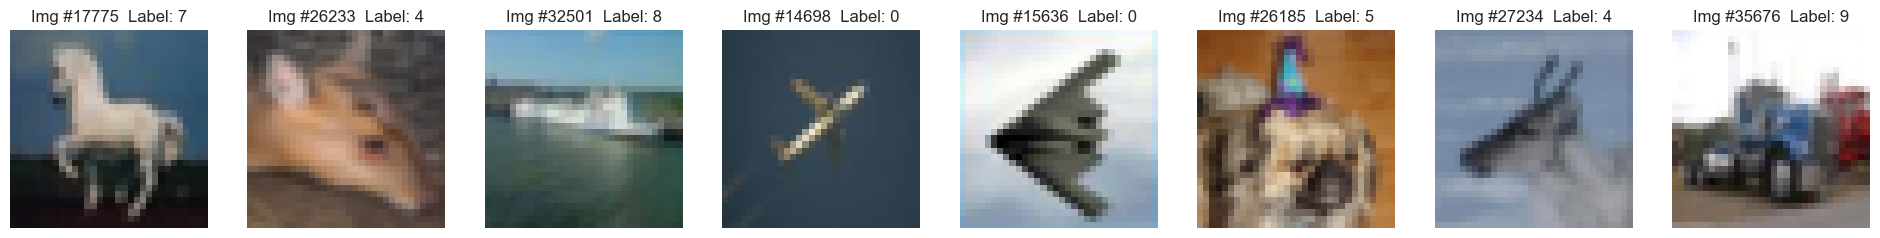

In [56]:
import matplotlib.pyplot as plt

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

print(f"Shape of a single image: {train_dataset[0][0].shape}")

print(f"Classes in CIFAR-10: {train_dataset.classes}")

N_IMGS = 8
fig, ax = plt.subplots(1,N_IMGS)
fig.set_size_inches(3 * N_IMGS, 3)

ids = np.random.randint(low=0, high=len(train_dataset), size=N_IMGS)

for i, n in enumerate(ids):
    img = train_dataset[n][0].numpy().transpose(1, 2, 0)
    ax[i].imshow(img)
    ax[i].set_title(f"Img #{n}  Label: {train_dataset[n][1]}")
    ax[i].axis("off")
plt.show()

In [57]:
# DataLoader MLP

BATCH_SIZE = 256
SHUFFLE_TRAIN = True
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=SHUFFLE_TRAIN)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)



class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.layers(x)


def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params


In [58]:
def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f

In [59]:

mplModel = MLP(input_size=32*32*3, hidden_size=1024, num_classes=len(train_dataset.classes))

In [60]:
from tqdm import tqdm

NUM_EPOCHS = 10
LR = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

mplModel.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mplModel.parameters(), lr=LR)



Using device: cpu


In [61]:
train_losses = []
val_losses = []
loss_list = []

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(train_loader, total=len(train_loader))
    for i, (imgs, labels) in enumerate(progress_bar):
        # using GPU
        imgs, labels = imgs.to(device), labels.to(device)
    
        # forward pass
        flattened_imgs = imgs.flatten(start_dim=1)
        preds = mplModel(flattened_imgs)
    
        # computing error
        loss = criterion(preds, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()
    
        # backprogating error to compute gradients
        loss.backward()
    
        # updating arameters
        optimizer.step()
    
        if(i % 10 == 0 or i == len(train_loader) - 1):
            progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    train_loss = loss.item()

    mplModel.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mplModel(images.flatten(start_dim=1))
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    mplModel.train()

Epoch 10 Iter 196: loss 1.40016. : 100%|██████████| 196/196 [00:02<00:00, 68.69it/s]


In [62]:
def plot_training_progress(loss_list):
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1,2)
    fig.set_size_inches(18,5)

    smooth_loss = smooth(loss_list, 31)
    ax[0].plot(loss_list, c="blue", label="Training Loss", linewidth=3, alpha=0.5)
    ax[0].plot(smooth_loss, c="red", label="Smoothed Loss", linewidth=3)
    ax[0].legend(loc="best")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("CE Loss")
    ax[0].set_title("Training Progress (linearscale)")

    ax[1].plot(loss_list, c="blue", label="Training Loss", linewidth=3, alpha=0.5)
    ax[1].plot(smooth_loss, c="red", label="Smoothed Loss", linewidth=3)
    ax[1].legend(loc="best")
    ax[1].set_xlabel("Iteration")
    ax[1].set_ylabel("CE Loss")
    ax[1].set_yscale("log")
    ax[1].set_title("Training Progress (logscale)")

    plt.show()

In [63]:
def plot_loss_curves(train_losses, val_losses):
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots()
    fig.set_size_inches(9, 5)

    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, c="blue", label="Train Loss", linewidth=3, marker="o")
    ax.plot(epochs, val_losses, c="red", label="Val Loss", linewidth=3, marker="o")
    ax.legend(loc="best")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("CE Loss")
    ax.set_title("Train vs. Val Loss per Epoch")

    plt.show()

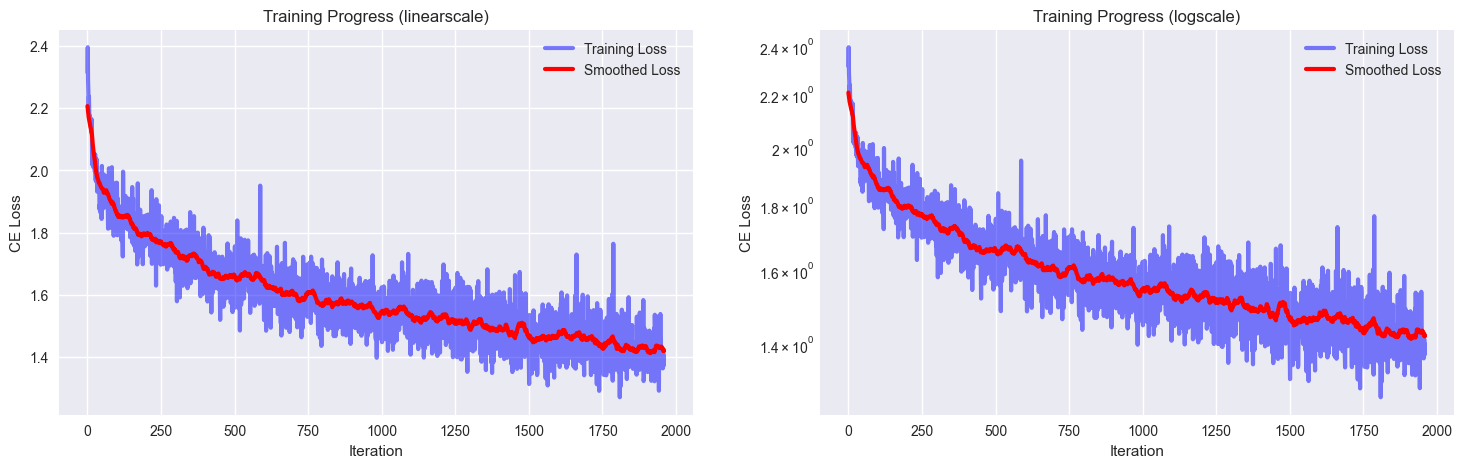

In [64]:
plot_training_progress(loss_list)

The left plot shows raw per-iteration cross-entropy loss; the smoothed red curve shows the overall downward trend more clearly. The log-scale plot on the right helps detect training plateaus.

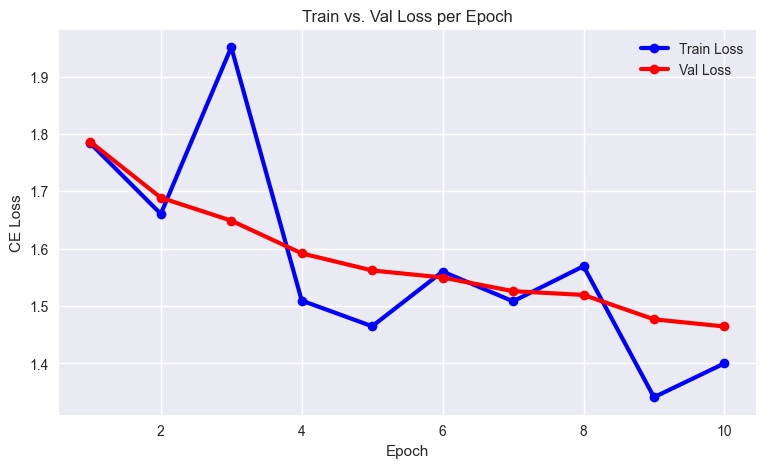

In [65]:
plot_loss_curves(train_losses, val_losses)

The train loss (blue) appears noisy because it records only the last batch loss per epoch, while the val loss (red) is smoother as it is averaged over all test batches. Both curves trend downward, and the lack of a growing gap indicates the MLP is not severely overfitting.

In [66]:
def evaluate_model(model, test_loader, test_dataset, device, flatten=True):
    n_correct = 0

    with torch.no_grad():
        progress_bar = tqdm(enumerate(test_loader), total=len(test_loader))
        for i, (imgs, labels) in progress_bar: 
            #everything needs to be on the same device
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            # forward pass
            if flatten:
                imgs = imgs.flatten(start_dim=1)
            preds = model(imgs)
            
            pred_labels = torch.argmax(torch.softmax(preds, dim=-1), dim=-1)
            cur_correct = len(torch.where(pred_labels == labels)[0])
            n_correct = n_correct + cur_correct

    accuracy = n_correct / len(test_dataset) * 100
    print(f"Test accuracy: {round(accuracy,2)}%")

In [67]:
evaluate_model(mplModel, test_loader, test_dataset, device)

100%|██████████| 40/40 [00:00<00:00, 97.54it/s]

Test accuracy: 48.44%


# CNN

In [68]:
class CNN(nn.Module):
    """ 
    Varation of LeNet: a simple CNN model
    for image classification.
    """
    def __init__(self, num_classes):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=32,  kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32 * 5 * 5, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=num_classes)
        )

        return
        
    def forward(self, x):
        """ Forward pass """
        
        x = self.encoder(x)
        x = self.decoder(x)
        # out2_flat = x.view(cur_b_size, -1)
        # y = self.fc(out2_flat)
        return x
    
def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params

In [69]:
cnn = CNN(num_classes=len(train_dataset.classes))

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 3e-4
cnn = cnn.to(device)

criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=cnn.parameters(), lr=LR)

In [71]:
train_losses = []
val_losses = []
loss_list = []

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(train_loader, total=len(train_loader))
    for i, (imgs, labels) in enumerate(progress_bar):
        # using GPU
        imgs, labels = imgs.to(device), labels.to(device)
    
        # forward pass
        preds = cnn(imgs)
    
        # computing error
        loss = criterion(preds, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()
    
        # backprogating error to compute gradients
        loss.backward()
    
        # updating arameters
        optimizer.step()
    
        if(i % 10 == 0 or i == len(train_loader) - 1):
            progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    train_loss = loss.item()

    cnn.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnn(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    cnn.train()

Epoch 10 Iter 196: loss 1.31661. : 100%|██████████| 196/196 [00:13<00:00, 14.48it/s]


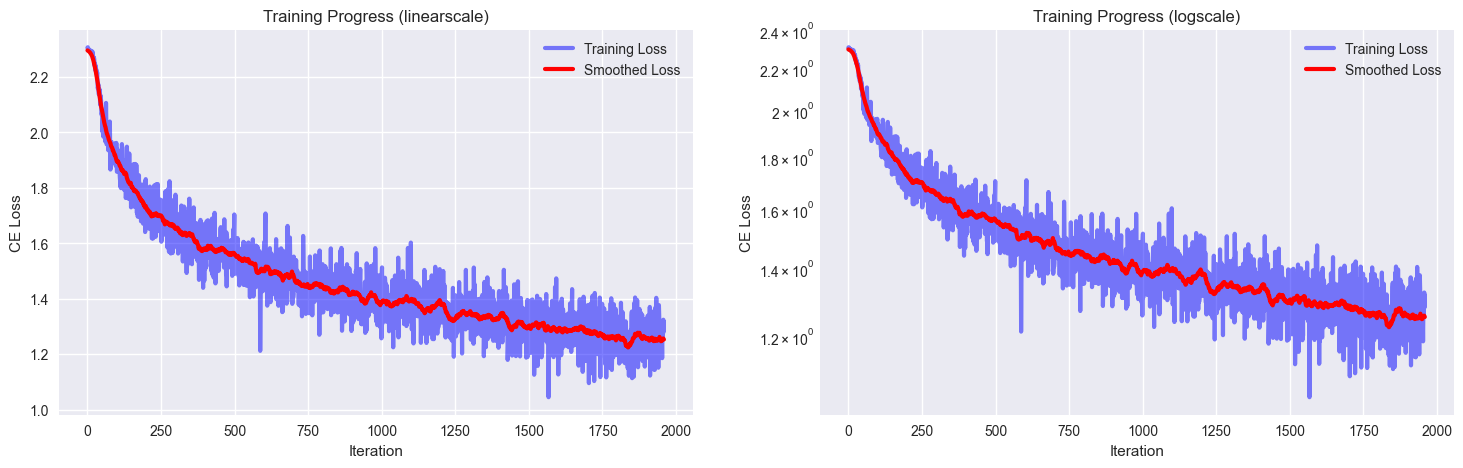

In [72]:
plot_training_progress(loss_list)

The smoothed loss curve confirms the CNN converges faster and to a lower loss than the MLP, reflecting its ability to exploit spatial structure in the images.

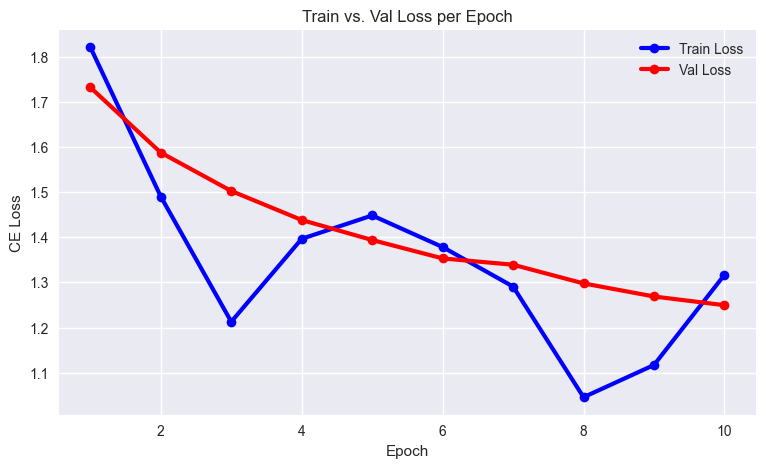

In [73]:
plot_loss_curves(train_losses, val_losses)

The train loss is noisy due to last-batch recording, but both curves follow a downward trend. The val loss tracking closely alongside train loss suggests the CNN generalizes well without significant overfitting.

In [74]:
evaluate_model(cnn, test_loader, test_dataset, device, flatten=False)

100%|██████████| 40/40 [00:00<00:00, 42.88it/s]

Test accuracy: 55.44%


The CNN achieves notably higher test accuracy than the MLP, demonstrating that convolutional layers are better suited for image classification than fully-connected layers alone.

# MLP with Dropout

In [75]:
class MLPDropout(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_p=0.5):
        super(MLPDropout, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

In [76]:
mlpDropoutModel = MLPDropout(input_size=32*32*3, hidden_size=1024, num_classes=len(train_dataset.classes))

In [77]:
LR = 2e-4

mlpDropoutModel.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlpDropoutModel.parameters(), lr=LR)

In [78]:
train_losses = []
val_losses = []
loss_list = []

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(train_loader, total=len(train_loader))
    for i, (imgs, labels) in enumerate(progress_bar):
        # using GPU
        imgs, labels = imgs.to(device), labels.to(device)

        # forward pass
        flattened_imgs = imgs.flatten(start_dim=1)
        preds = mlpDropoutModel(flattened_imgs)

        # computing error
        loss = criterion(preds, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()

        # backprogating error to compute gradients
        loss.backward()

        # updating arameters
        optimizer.step()

        if(i % 10 == 0 or i == len(train_loader) - 1):
            progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    train_loss = loss.item()

    mlpDropoutModel.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = mlpDropoutModel(images.flatten(start_dim=1))
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    mlpDropoutModel.train()

Epoch 10 Iter 196: loss 1.66503. : 100%|██████████| 196/196 [00:03<00:00, 62.21it/s]


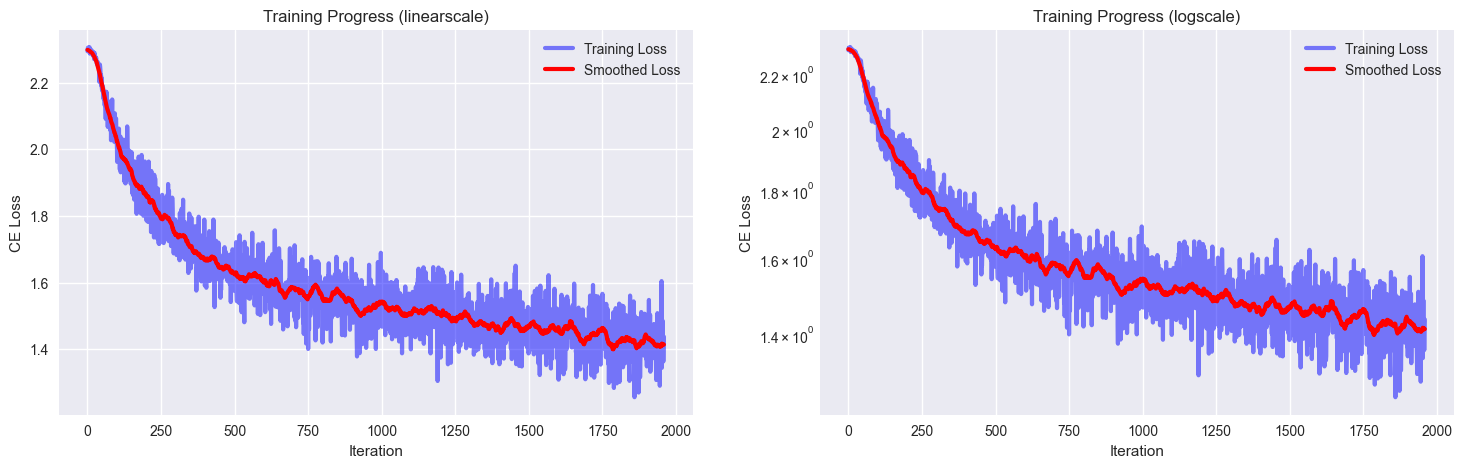

In [101]:
plot_training_progress(loss_list)

The per-iteration loss curve for the MLP with dropout shows slightly noisier behavior due to random unit deactivation, but the overall trend still decreases over time.

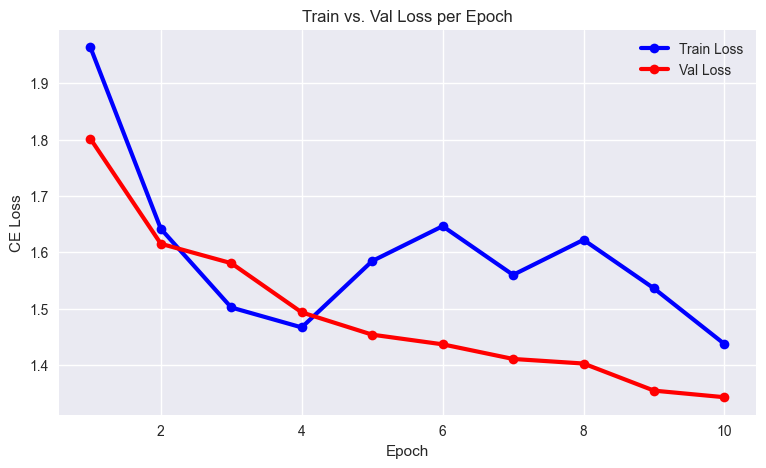

In [102]:
plot_loss_curves(train_losses, val_losses)

The val loss (red) decreases smoothly from ~1.80 to ~1.33, ending clearly below the noisy train loss (~1.43), which reflects good generalization. The train loss is erratic due to last-batch recording, but the overall downward trend confirms the model is still learning.

In [100]:
evaluate_model(mlpDropoutModel, test_loader, test_dataset, device)

100%|██████████| 40/40 [00:00<00:00, 96.96it/s]

Test accuracy: 46.0%


The MLP with dropout reaches 46.0% test accuracy, slightly below the plain MLP's 47.88%. The small gap suggests dropout has a mild underfitting effect here — with only 10 epochs and one hidden layer, the model does not overfit enough for dropout to provide a benefit.

# CNN with Dropout

In [103]:
class CNNDropout(nn.Module):
    def __init__(self, num_classes, dropout_p=0.5):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32 * 5 * 5, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features=128, out_features=num_classes)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [104]:
cnnDropout = CNNDropout(num_classes=len(train_dataset.classes))

In [105]:
LR = 3e-4
cnnDropout = cnnDropout.to(device)

criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=cnnDropout.parameters(), lr=LR)

In [106]:
train_losses = []
val_losses = []
loss_list = []

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(train_loader, total=len(train_loader))
    for i, (imgs, labels) in enumerate(progress_bar):
        # using GPU
        imgs, labels = imgs.to(device), labels.to(device)

        # forward pass
        preds = cnnDropout(imgs)

        # computing error
        loss = criterion(preds, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()

        # backprogating error to compute gradients
        loss.backward()

        # updating arameters
        optimizer.step()

        if(i % 10 == 0 or i == len(train_loader) - 1):
            progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

    train_loss = loss.item()

    cnnDropout.eval()
    val_loss = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cnnDropout(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    cnnDropout.train()

Epoch 10 Iter 196: loss 1.48303. : 100%|██████████| 196/196 [00:14<00:00, 13.85it/s]


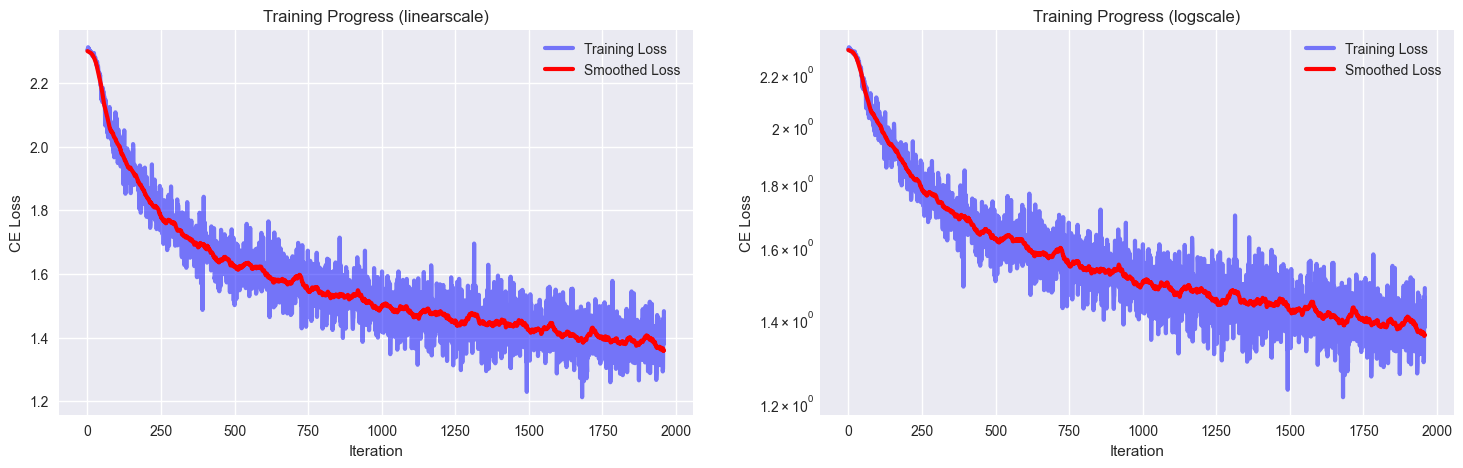

In [107]:
plot_training_progress(loss_list)

The CNN with dropout shows a similar convergence pattern to the plain CNN, with the smoothed curve indicating stable learning despite the added stochasticity.

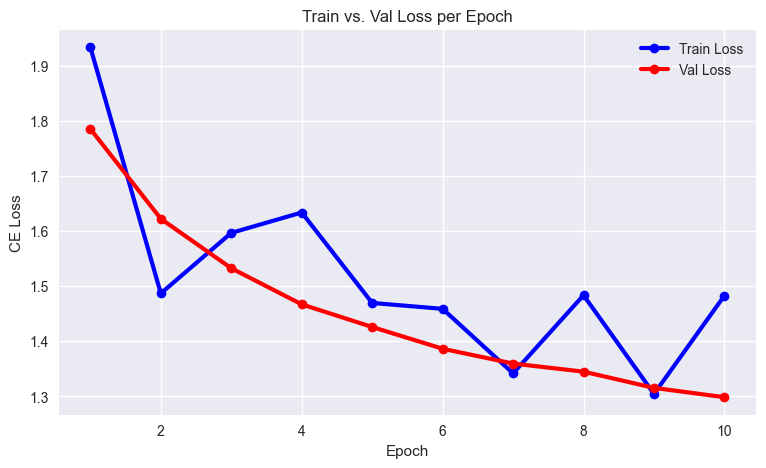

In [108]:
plot_loss_curves(train_losses, val_losses)

The val loss (red) decreases smoothly from ~1.79 to ~1.30, ending clearly below the noisy train loss (~1.48). Both curves trend downward with no sign of divergence, indicating the CNN with dropout generalizes well and is not overfitting within 10 epochs.

In [109]:
evaluate_model(cnnDropout, test_loader, test_dataset, device, flatten=False)

100%|██████████| 40/40 [00:00<00:00, 43.83it/s]

Test accuracy: 49.99%


The CNN with dropout achieves 49.99% test accuracy, notably below the plain CNN's 55.86%. Dropout causes a significant performance drop here, suggesting the convolutional features are not redundant enough to benefit from random deactivation at this training scale.

# Model Analysis

In [110]:
def plot_confusion_matrix(model, test_loader, test_dataset, device, flatten=True):
    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if flatten:
                imgs = imgs.flatten(start_dim=1)
            preds = model(imgs)
            pred_labels = torch.argmax(torch.softmax(preds, dim=-1), dim=-1)
            all_preds.extend(pred_labels.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    classes = test_dataset.classes
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    for t, p in zip(all_labels, all_preds):
        cm[t][p] += 1

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, cmap="Blues")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")

    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)

    plt.tight_layout()
    plt.show()

In [111]:
def visualize_predictions(model, test_dataset, device, flatten=True, n=16):
    indices = np.random.randint(0, len(test_dataset), size=n)
    classes = test_dataset.classes

    model.eval()
    fig, axes = plt.subplots(2, n // 2, figsize=(3 * n // 2, 6))
    axes = axes.flatten()

    with torch.no_grad():
        for plot_i, idx in enumerate(indices):
            img, label = test_dataset[idx]
            inp = img.unsqueeze(0).to(device)
            if flatten:
                inp = inp.flatten(start_dim=1)
            pred = model(inp)
            pred_label = torch.argmax(torch.softmax(pred, dim=-1), dim=-1).item()

            axes[plot_i].imshow(img.numpy().transpose(1, 2, 0))
            axes[plot_i].axis("off")
            correct = pred_label == label
            color = "green" if correct else "red"
            axes[plot_i].set_title(
                f"T: {classes[label]}\nP: {classes[pred_label]}",
                color=color, fontsize=8
            )

    plt.suptitle("Green = correct, Red = wrong", fontsize=11)
    plt.tight_layout()
    plt.show()

## MLP

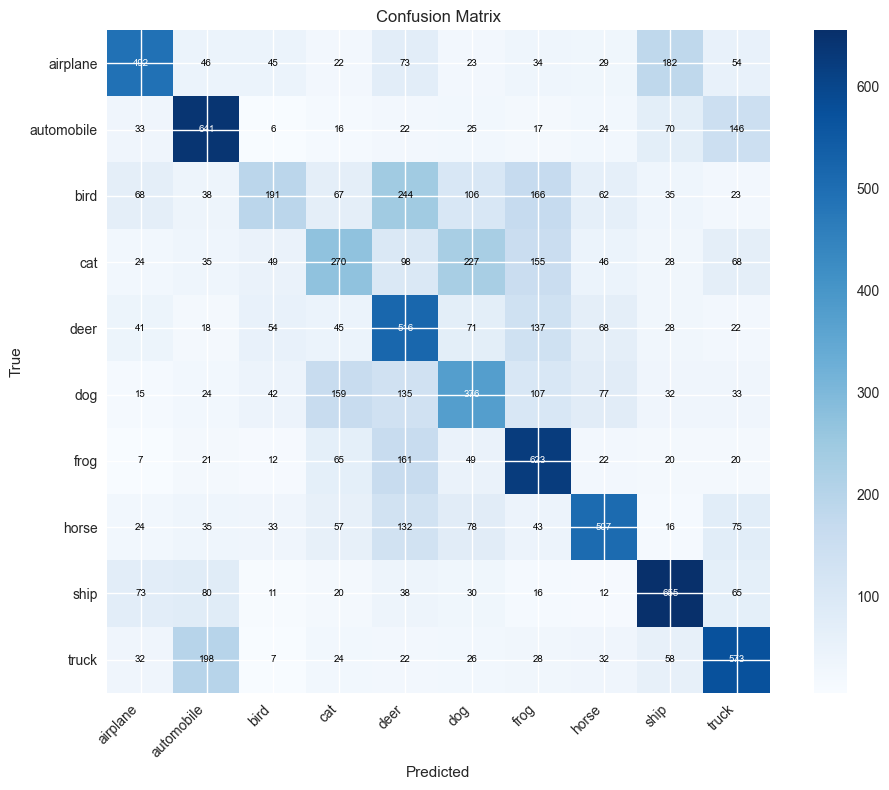

In [112]:
plot_confusion_matrix(mplModel, test_loader, test_dataset, device, flatten=True)

High values along the diagonal indicate correct predictions; off-diagonal hotspots reveal which class pairs the MLP confuses most, such as cat/dog or automobile/truck.

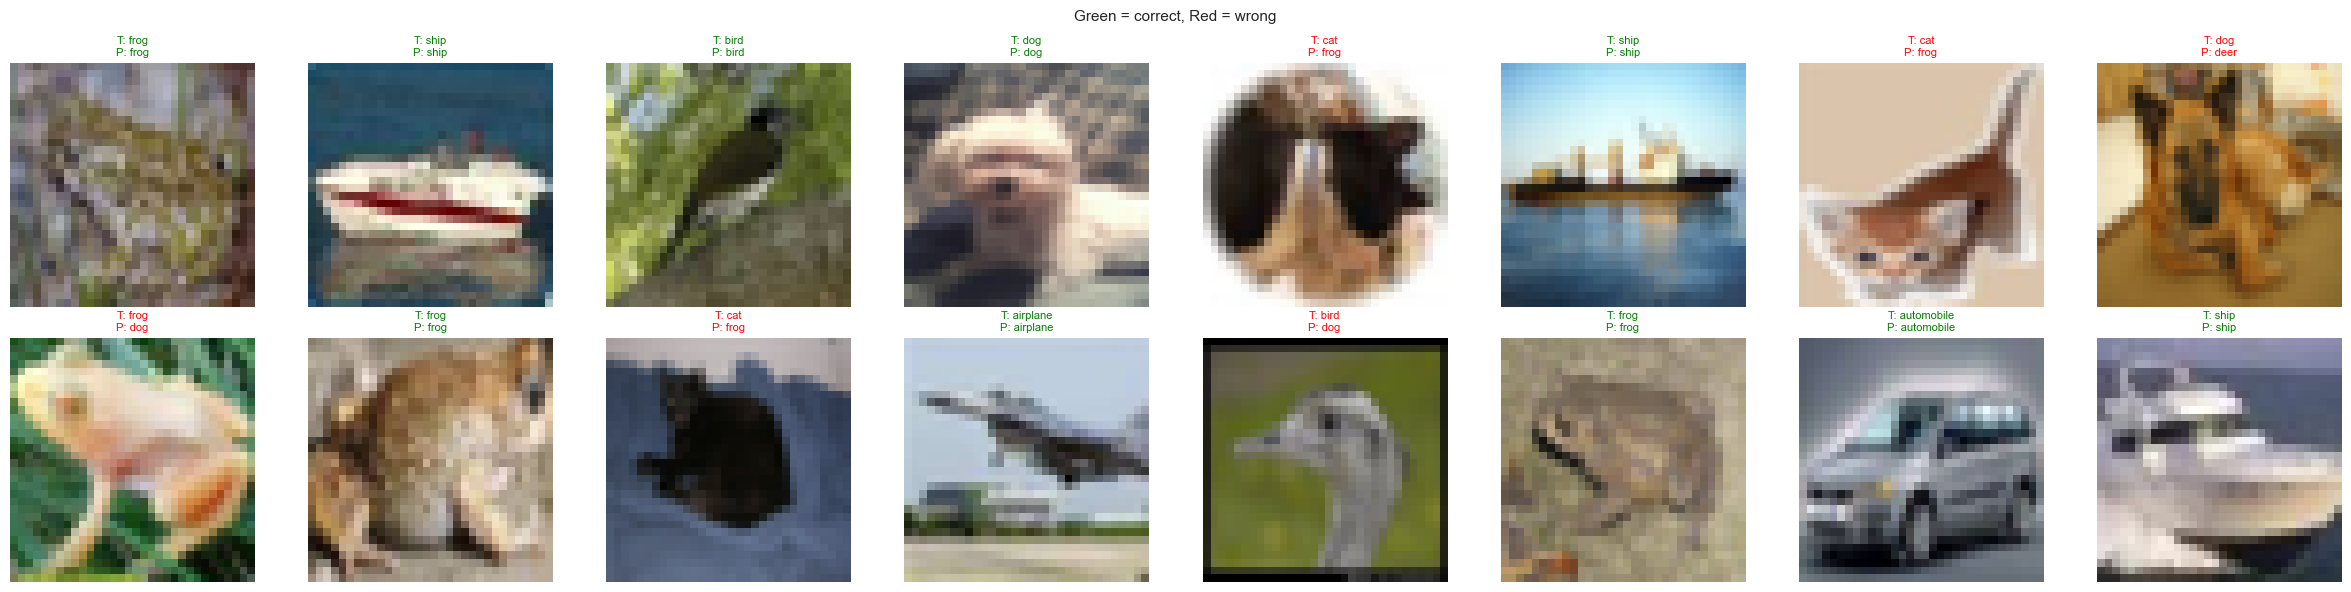

In [113]:
visualize_predictions(mplModel, test_dataset, device, flatten=True)

Red titles highlight misclassified images, making it easy to spot which visual patterns fool the MLP — typically fine-grained textures or inter-class similarity.

## CNN

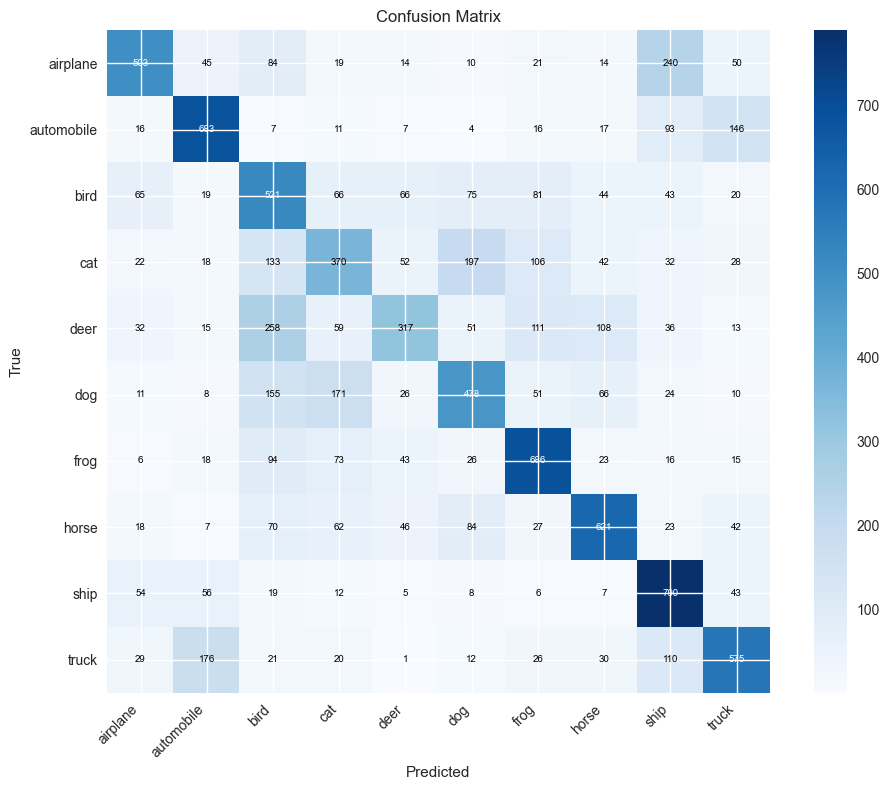

In [114]:
plot_confusion_matrix(cnn, test_loader, test_dataset, device, flatten=False)

The CNN's confusion matrix is generally cleaner along the diagonal than the MLP's, reflecting its stronger feature extraction through convolution.

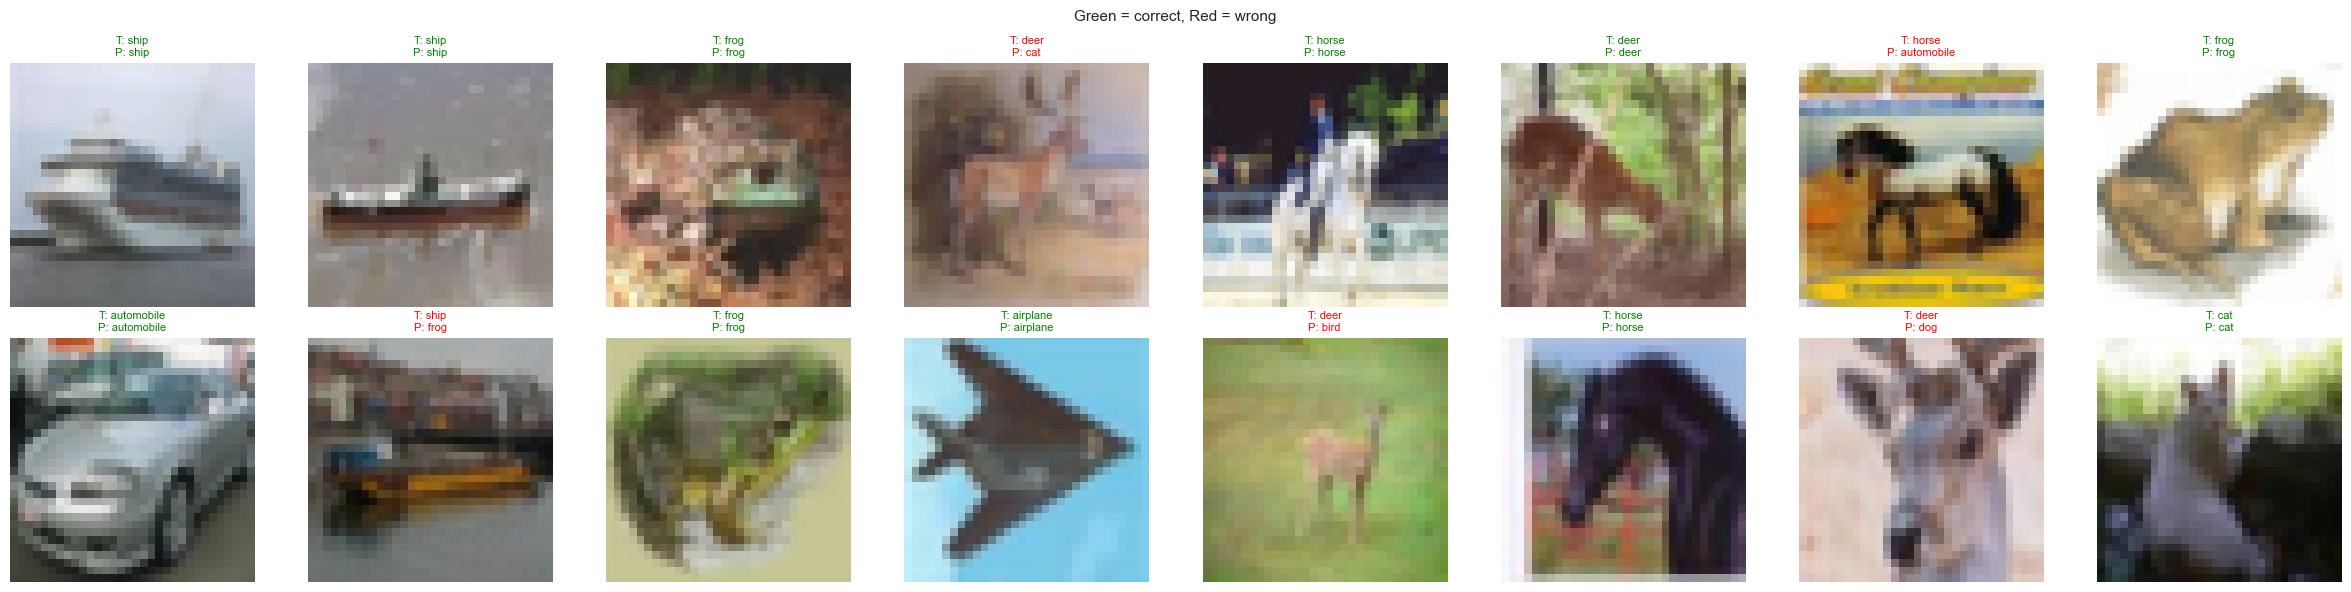

In [115]:
visualize_predictions(cnn, test_dataset, device, flatten=False)

The CNN still struggles with visually similar classes, but the proportion of red-titled images should be lower than for the MLP, consistent with its higher accuracy.

## MLP with Dropout

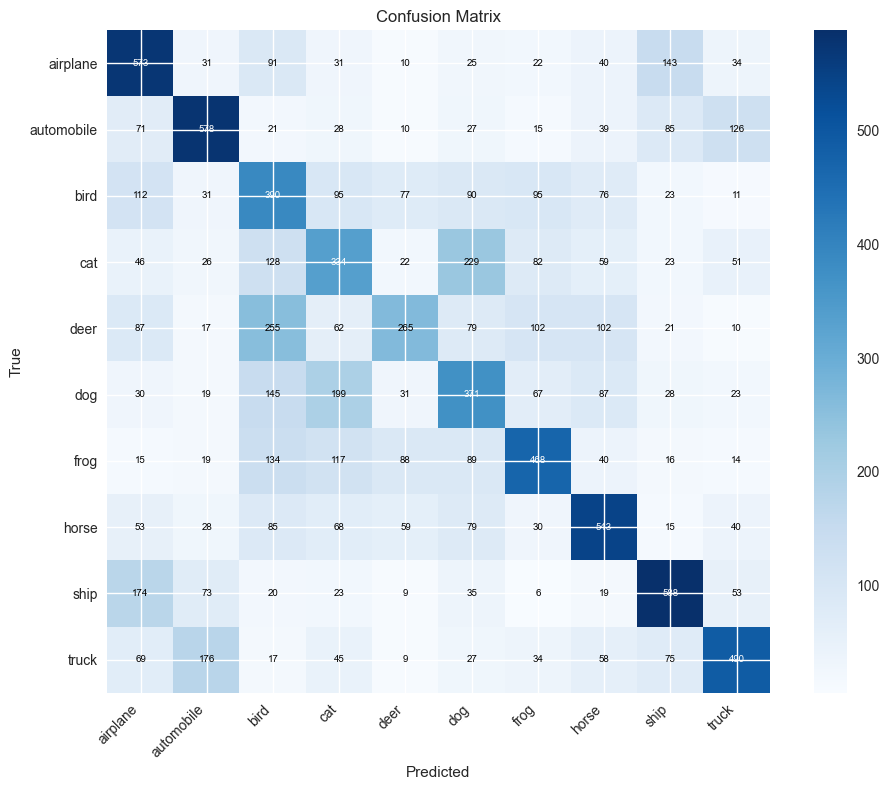

In [116]:
plot_confusion_matrix(mlpDropoutModel, test_loader, test_dataset, device, flatten=True)

The MLP Dropout confusion matrix shows whether regularization shifted errors — ideally spreading mistakes more evenly rather than concentrating them on hard class pairs.

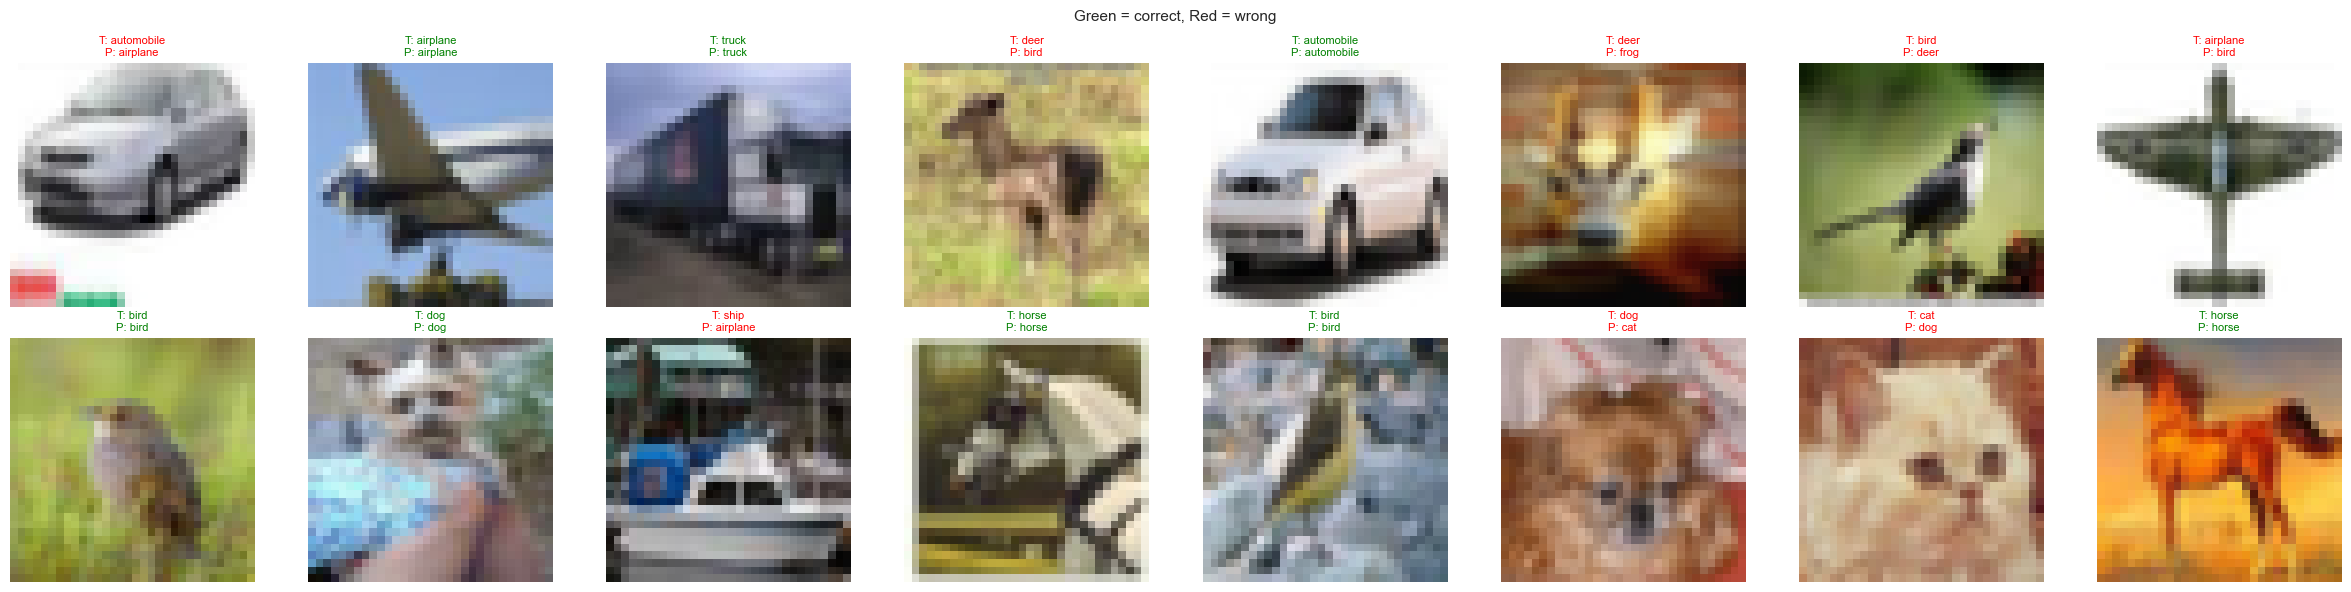

In [117]:
visualize_predictions(mlpDropoutModel, test_dataset, device, flatten=True)

Failure cases for the MLP with dropout tend to overlap with those of the plain MLP, since dropout does not change what features the model learns, only how reliably.

## CNN with Dropout

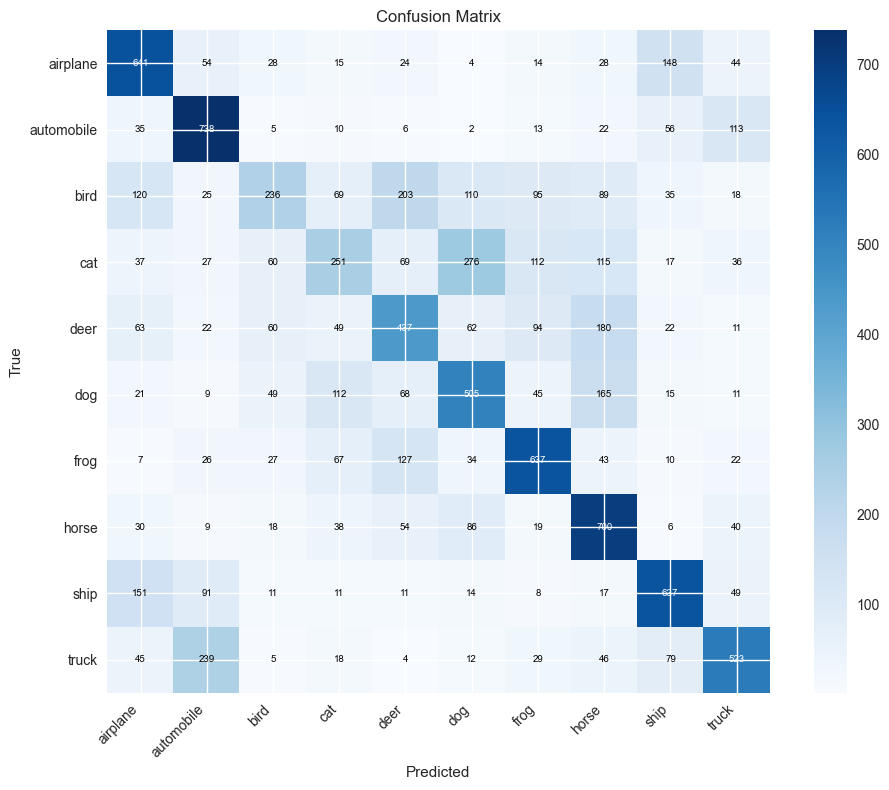

In [118]:
plot_confusion_matrix(cnnDropout, test_loader, test_dataset, device, flatten=False)

The CNN Dropout confusion matrix should show a similar pattern to the plain CNN, with potential improvement on the classes where the plain model overfit.

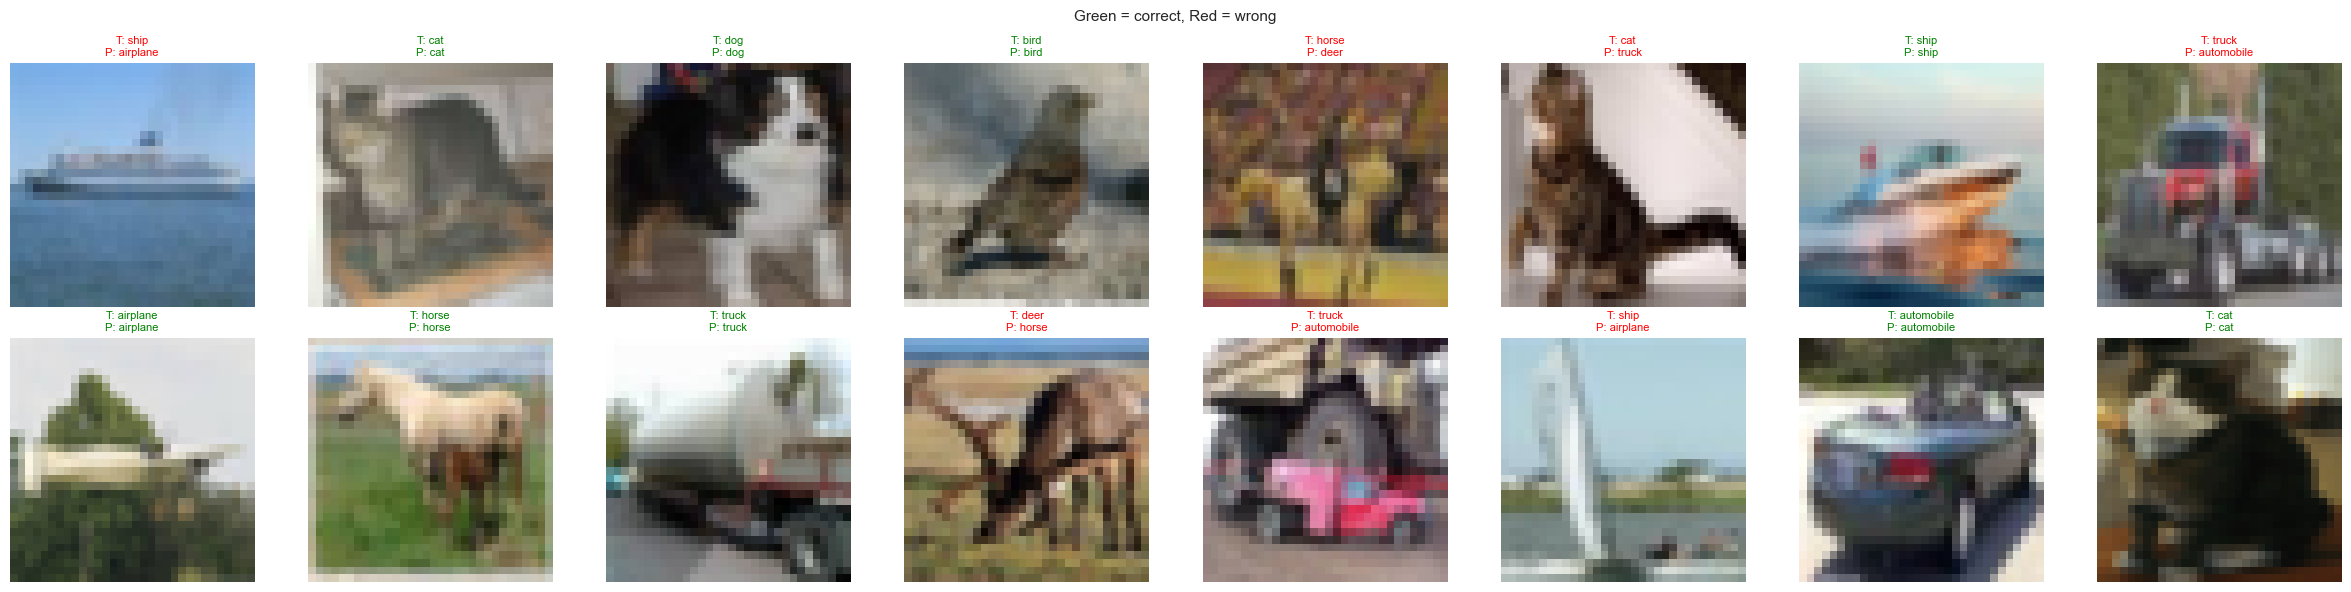

In [119]:
visualize_predictions(cnnDropout, test_dataset, device, flatten=False)

Comparing failure images across all four models highlights which samples are universally hard — these typically involve ambiguous viewpoints, occlusion, or inter-class similarity.